In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from datetime import date, datetime, timedelta

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

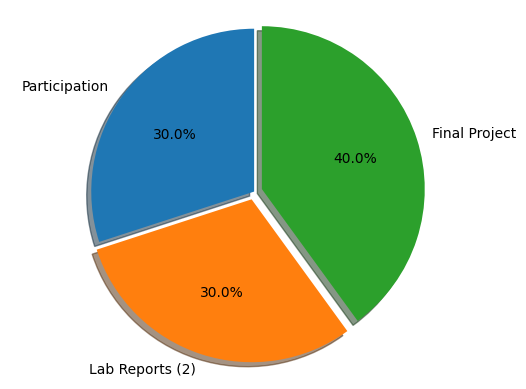

In [2]:
# Data
sizes = [30, 30, 40]
labels = ['Participation', 'Lab Reports (2)', 'Final Project']
explode = (0, 0.05, 0.05)  # only "explode" the 2nd slice (i.e. 'Hogs')


# Create the pie chart
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
       shadow=True, startangle=90)

# Ensure the plot is a circle
plt.axis('equal') 

# Display the chart
plt.show()

In [4]:
ticker=['SPY']
data = yf.download(ticker, period='2y', multi_level_index=False)
#calculate daily returns
data=data.reset_index()
data

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2024-05-20,517.466553,518.930915,516.597684,516.988204,37764200
1,2024-05-21,518.735535,518.891767,516.499964,516.704996,33437000
2,2024-05-22,517.241943,518.755105,515.064885,518.042468,48390000
3,2024-05-23,513.463867,520.404928,512.253278,520.297556,57211200
4,2024-05-24,516.861145,517.671442,514.361970,515.308895,41291100
...,...,...,...,...,...,...
496,2026-05-13,742.309998,743.909973,735.469971,738.469971,44200200
497,2026-05-14,748.169983,749.530029,743.559998,743.650024,45307600
498,2026-05-15,739.169983,743.460022,737.960022,741.789978,60410800
499,2026-05-18,738.650024,741.419983,733.390015,739.830017,47723100


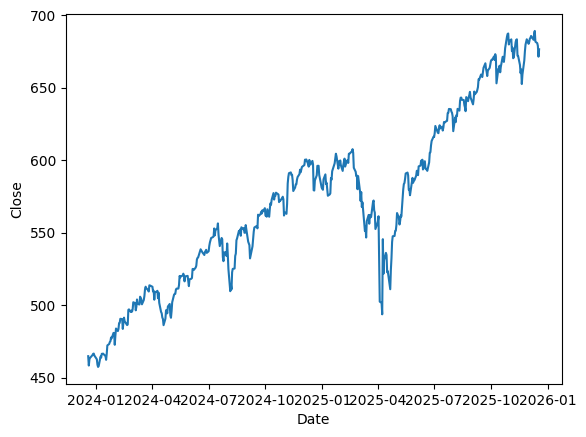

In [4]:
sns.lineplot(data=data, x='Date', y='Close');

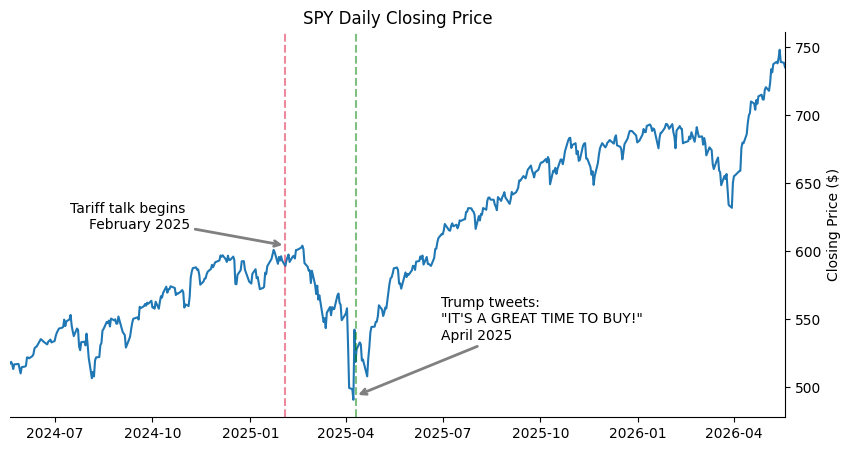

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.despine(top=True, left=True, right=False)
sns.lineplot(data=data, x='Date', y='Close').set_title('SPY Daily Closing Price')
#format plot
ax.set(xlabel='', ylabel='Closing Price ($)')
#plt.xticks(rotation=45)
ax.margins(x=0, y=0.05)
# Move the y-axis ticks to the right
ax.yaxis.tick_right()
# Move the y-axis label to the right
ax.yaxis.set_label_position("right")

#annotation
tariff_day=datetime(2025,2,3) #tariff talk begins
plt.axvline(x=tariff_day, color='crimson', alpha=0.5, linestyle='--')
#crash begins
plt.annotate(
    'Tariff talk begins \nFebruary 2025',          # The text label
    xy=(tariff_day,data.loc[data.Date==tariff_day].Close.values[0]+15),          # The point to annotate (arrow points here)
    xytext=(tariff_day-timedelta(days=90),625), # The position of the text

    arrowprops=dict(
        arrowstyle="->",      # Arrow style (e.g., simple arrow head)
        color='grey',          # Arrow color
        lw=2                  # Line width
    ),
    fontsize=10,              # Font size of the text
    ha='right',
    va='center'
)
tweet=datetime(2025,4,10)
plt.axvline(x=tweet, color='green', alpha=0.5, linestyle='--')
plt.annotate(
    'Trump tweets: \n"IT\'S A GREAT TIME TO BUY!" \nApril 2025',
    xy=(tweet,data.loc[data.Date==tweet].Close.values[0]-25),          
    xytext=(tweet+timedelta(days=80),550), 

    arrowprops=dict(
        arrowstyle="->",     
        color='grey',          
        lw=2                 
    ),
    fontsize=10,              
    ha='left',
    va='center'
);
plt.savefig('images/SPY.png')

In [112]:
ticker=['SPY']
data = yf.download(ticker, period='1mo', multi_level_index=False)
#calculate daily returns
data=data.reset_index()

[*********************100%***********************]  1 of 1 completed


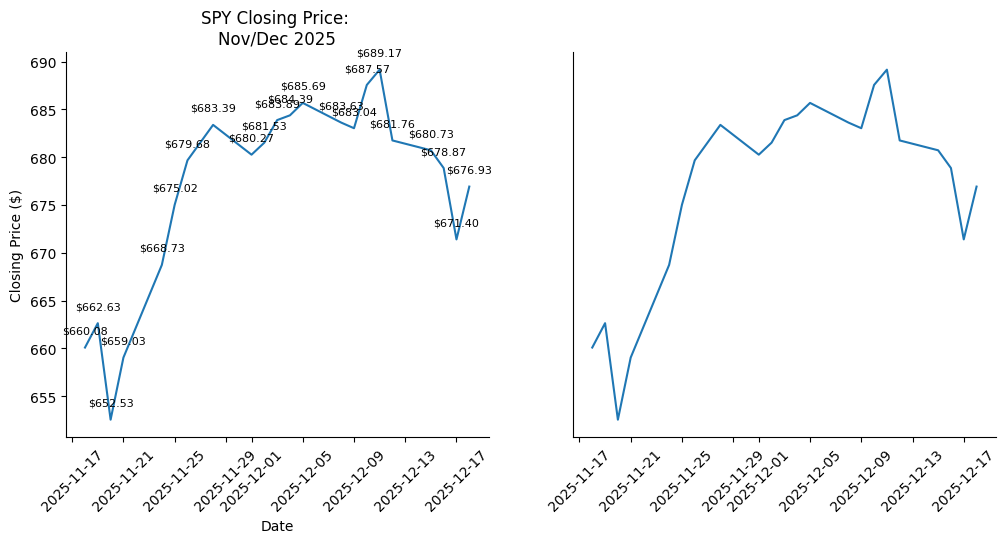

In [138]:
fig, ax = plt.subplots(1,2,figsize=(12, 5))
sns.despine(top=True,right=True)

#too much
sns.lineplot(data=data,x='Date', y='Close', markers=True,ax=ax[0]).set_title('SPY Closing Price: \nNov/Dec 2025')
ax[0].set(xlabel='Date',ylabel='Closing Price ($)')
ax[0].tick_params(axis='x', rotation=45)
for x, y in zip(data.Date, data.Close):
    # Add the annotation
    # xy is the point location (x, y)
    # textcoords='offset points' means xytext is an offset from xy
    # ha='center' aligns the text horizontally
    ax[0].annotate(
        f"${y:,.2f}",              # The text label (formatted as a string)
        xy=(x, y),           # The point to label
        xytext=(0, 10),      # Offset (x, y) from the point
        textcoords="offset points", 
        ha='center',         
        fontsize=8
    );

#too little
sns.lineplot(data=data,x='Date', y='Close', markers=True,ax=ax[1])
ax[1].set(xlabel='', ylabel='')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_yticks([]) #
ax[1].set_yticklabels([]);

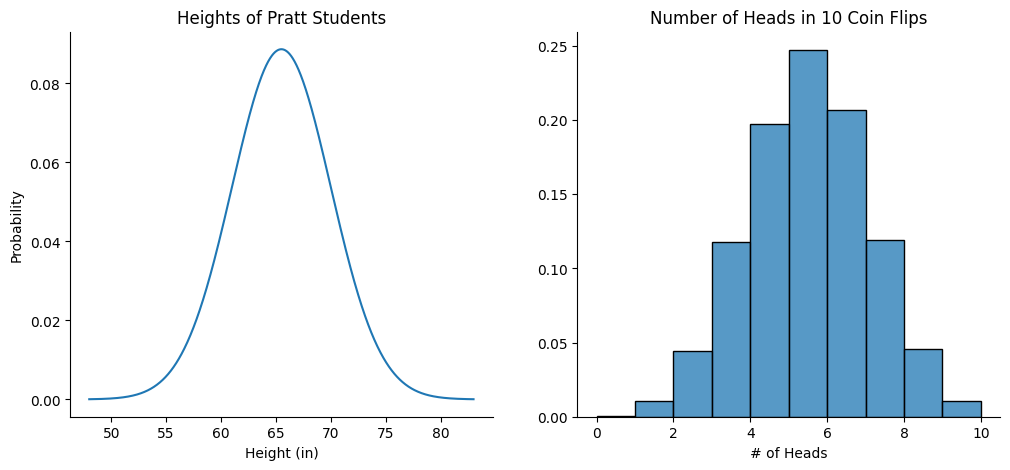

In [33]:
fig, ax = plt.subplots(1,2,figsize=(12, 5))
sns.despine(top=True,right=True)

x=np.linspace(48,83,1000)
y = stats.norm.pdf(x, loc=(48+83)/2, scale=4.5)
sns.lineplot(x=x, y=y, ax=ax[0]).set_title('Heights of Pratt Students')
ax[0].set(xlabel='Height (in)', ylabel='Probability')

x=[np.random.binomial(n=10,p=0.5) for x in range(0,10000)]
sns.histplot(x=x, binwidth=1, stat='probability').set_title('Number of Heads in 10 Coin Flips')
ax[1].set(xlabel='# of Heads', ylabel='');

In [ ]:
pd.DataFrame